In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumBarunGothic'

In [ ]:
df_2019 = pd.read_csv("seoul_area_2019.csv")
df_2020 = pd.read_csv("seoul_area_2020.csv")
df_2021 = pd.read_csv("seoul_area_2021.csv")
df_2022 = pd.read_csv("seoul_area_2022.csv")
df_2023 = pd.read_csv("seoul_area_2023.csv")
df_2024 = pd.read_csv("seoul_area_2024.csv")

In [ ]:
#컬럼명 확인
print(df_2019.columns.tolist())
print(df_2020.columns.tolist())
print(df_2021.columns.tolist())
print(df_2022.columns.tolist())
print(df_2023.columns.tolist())
print(df_2024.columns.tolist())

['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수']
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수']
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수']
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수']
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수']


In [ ]:
df_2020[['기준_년분기_코드','상권_구분_코드','서비스_업종_코드_명','개업_점포_수','폐업_점포_수']]

In [ ]:
df_2020['상권_구분_코드'].value_counts()

상권_구분_코드
A    192026
D     72275
R     44090
U      2068
Name: count, dtype: int64

기준 년분기에 따른 개업점포수 와 폐업점포수


In [87]:
import glob

df_seoul_area = pd.DataFrame()

for file in glob.glob('seoul_area_*.csv'):
    df = pd.read_csv(file)
    df_columns = df[['기준_년분기_코드','개업_점포_수','폐업_점포_수']]
    df_seoul_area = pd.concat([df_seoul_area,df_columns],ignore_index=True)


df_seoul_area = df_seoul_area.groupby('기준_년분기_코드')[['개업_점포_수','폐업_점포_수']].sum().reset_index()

print(df_seoul_area)

    기준_년분기_코드  개업_점포_수  폐업_점포_수
0       20191    18705    12603
1       20192    18056    13353
2       20193    17970    13936
3       20194    18369    12464
4       20201    18206    15168
5       20202    16192    10913
6       20203    15430    13184
7       20204    16842    13351
8       20211    13552    13257
9       20212    15561    13686
10      20213    13750    12433
11      20214    18518    12129
12      20221    13034    11120
13      20222    13792     9087
14      20223    14146    15302
15      20224    19434    12645
16      20231    16827    15316
17      20232    16973    14014
18      20233    16699    14645
19      20234    15067    13219
20      20241    13818    16672
21      20242    12136    14697
22      20243    10971    14792
23      20244    10577    12814


시각화 (선그래프)

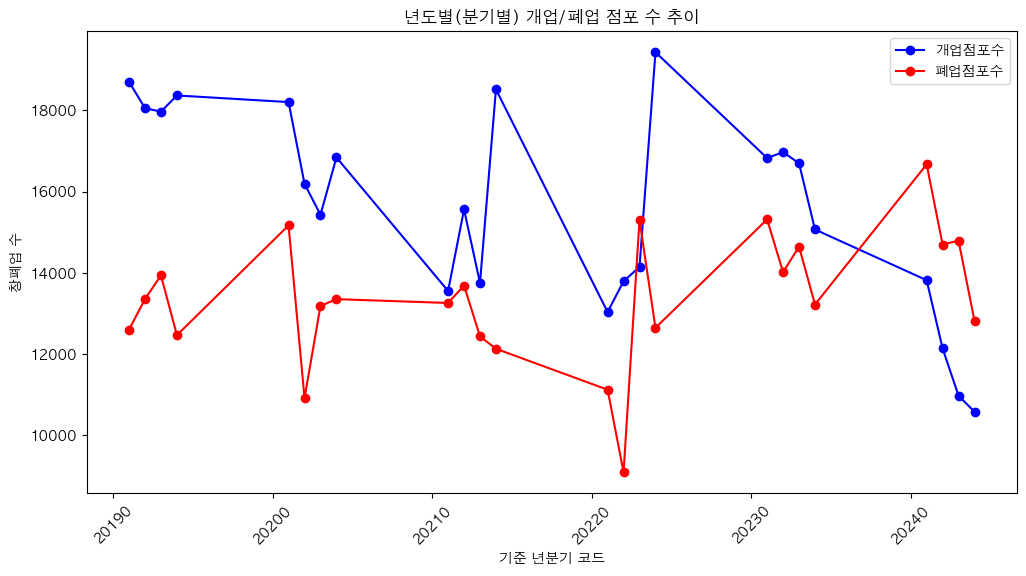

In [88]:
from matplotlib import rc

rc('font', family='AppleGothic') 		
plt.rcParams['axes.unicode_minus'] = False
df_seoul_area = df_seoul_area.reset_index()
plt.figure(figsize=(12,6))
plt.plot(df_seoul_area['기준_년분기_코드'],df_seoul_area['개업_점포_수'],label='개업점포수',color='blue',marker='o')
plt.plot(df_seoul_area['기준_년분기_코드'],df_seoul_area['폐업_점포_수'],label='폐업점포수',color='red',marker='o')

plt.xticks(rotation=45)
plt.xlabel('기준 년분기 코드')
plt.ylabel('창폐업 수')
plt.title('년도별(분기별) 개업/폐업 점포 수 추이')
plt.legend()
plt.show()


서울시 생필품 농수축산물 가격 정보


In [54]:
df_price = pd.read_csv("seoul_price_index.csv")

In [55]:
print(df_price.columns.tolist())

['시점', '총지수', '식료품 및 비주류음료', '식료품 및 비주류음료.1', '식료품 및 비주류음료.2', '주류·담배', '주류·담배.1', '주류·담배.2', '의복·신발', '의복·신발.1', '의복·신발.2', '주택·수도·전기 및 연료', '주택·수도·전기 및 연료.1', '주택·수도·전기 및 연료.2', '주택·수도·전기 및 연료.3', '주택·수도·전기 및 연료.4', '가정용품 및 가사서비스', '가정용품 및 가사서비스.1', '가정용품 및 가사서비스.2', '가정용품 및 가사서비스.3', '가정용품 및 가사서비스.4', '가정용품 및 가사서비스.5', '가정용품 및 가사서비스.6', '보건', '보건.1', '보건.2', '보건.3', '교통', '교통.1', '교통.2', '교통.3', '통신', '통신.1', '통신.2', '통신.3', '오락 및 문화', '오락 및 문화.1', '오락 및 문화.2', '오락 및 문화.3', '오락 및 문화.4', '오락 및 문화.5', '오락 및 문화.6', '교육', '교육.1', '교육.2', '교육.3', '음식 및 숙박', '음식 및 숙박.1', '음식 및 숙박.2', '기타 상품 및 서비스', '기타 상품 및 서비스.1', '기타 상품 및 서비스.2', '기타 상품 및 서비스.3']


In [65]:
df_price = df_price[['시점','총지수']]
print(df_price)

          시점     총지수
1   2019. 01   98.76
2   2019. 02   99.26
3   2019. 03   99.06
4   2019. 04   99.44
5   2019. 05   99.49
..       ...     ...
68  2024. 08  113.94
69  2024. 09  113.92
70  2024. 10  114.04
71  2024. 11  113.73
72  2024. 12  114.24

[72 rows x 2 columns]


In [72]:
df_price['시점'] = df_price['시점'].astype(str)
df_price['총지수'] = df_price['총지수'].astype(float)
df_price['시점'] = df_price['시점'].str.replace('.','').str.replace(' ','')

groups = []
for i in range(0,len(df_price),3):
    group_key = df_price.iloc[i]['시점']
    groups += [group_key] * 3

df_price = df_price.iloc[:len(groups)]
df_price['분기'] = groups

df_quart = df_price.groupby('분기')['총지수'].sum().reset_index()

print(df_quart)

        분기     총지수
0   201901  297.08
1   201904  298.29
2   201907  298.23
3   201910  298.98
4   202001  299.47
5   202004  299.17
6   202007  300.71
7   202010  300.64
8   202101  303.76
9   202104  305.10
10  202107  306.88
11  202110  309.42
12  202201  313.88
13  202204  318.87
14  202207  322.90
15  202210  324.58
16  202301  328.59
17  202304  330.81
18  202307  334.40
19  202310  336.74
20  202401  338.69
21  202404  339.96
22  202407  341.32
23  202410  342.01


In [73]:
df_quart['총지수'] = (df_quart['총지수']/3).round(2)
print(df_quart)

        분기     총지수
0   201901   99.03
1   201904   99.43
2   201907   99.41
3   201910   99.66
4   202001   99.82
5   202004   99.72
6   202007  100.24
7   202010  100.21
8   202101  101.25
9   202104  101.70
10  202107  102.29
11  202110  103.14
12  202201  104.63
13  202204  106.29
14  202207  107.63
15  202210  108.19
16  202301  109.53
17  202304  110.27
18  202307  111.47
19  202310  112.25
20  202401  112.90
21  202404  113.32
22  202407  113.77
23  202410  114.00


In [85]:
import re

def fix(val):
    val = str(val)
    val = re.sub(r'04$','02',val)
    val = re.sub(r'07$','03',val)
    val = re.sub(r'10$','04',val)
    val = re.sub(r'12$','04',val)
    return val

df_quart['분기'] = df_quart['분기'].apply(fix)
print(df_quart)

        분기     총지수
0   201901   99.03
1   201902   99.43
2   201903   99.41
3   201904   99.66
4   202001   99.82
5   202002   99.72
6   202003  100.24
7   202004  100.21
8   202101  101.25
9   202102  101.70
10  202103  102.29
11  202104  103.14
12  202201  104.63
13  202202  106.29
14  202203  107.63
15  202204  108.19
16  202301  109.53
17  202302  110.27
18  202303  111.47
19  202304  112.25
20  202401  112.90
21  202402  113.32
22  202403  113.77
23  202404  114.00


서울시 2019~2024 분기별 물가 총지수 그래프

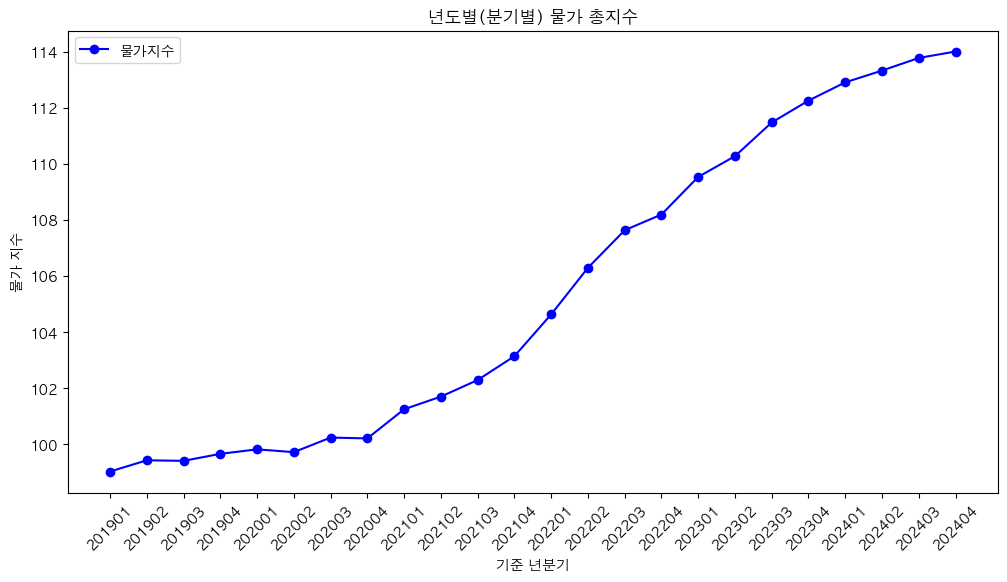

In [86]:
from matplotlib import rc

rc('font', family='AppleGothic') 		
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12,6))
plt.plot(df_quart['분기'],df_quart['총지수'],label='물가지수',color='blue',marker='o')

plt.xticks(rotation=45)
plt.xlabel('기준 년분기')
plt.ylabel('물가 지수')
plt.title('년도별(분기별) 물가 총지수')
plt.legend()
plt.show()